In [1]:
import os
import re
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def normalize_legal_name(name):
    """
    Creates a 'fingerprint' for comparison by removing legal noise.
    """
    if not name: return ""
    n = name.lower()
    # Remove m/s, versus, v., and common suffixes
    n = re.sub(r'\bm/s\.?\b|\bversus\b|\bv\.?s?\.?\b', ' ', n)
    n = re.sub(r'\band\s+(?:ors?|anr\.?)\b', ' ', n)
    # Return only alphanumeric for a 'fuzzy' match
    return re.sub(r'[^a-z0-9]', '', n)

In [3]:
def extract_precedents(text):
    """
    Captures [Party A] v. [Party B] while avoiding long sentences.
    """
    # Restrict the number of characters allowed around 'v.' to prevent paragraph capture
    pattern = r"([A-Z][\w\s\.&]{2,40} v\. [A-Z][\w\s\.&]{2,40})"
    found = re.findall(pattern, text)
    
    cleaned = []
    # These anchors help us cut off sentences that bleed into the citation
    noise_anchors = [
        r' held', r' observed', r' affirmed', r' clarified', r' relied', 
        r' mentioned', r' indicates', r' adopted', r' considered', 
        r' according', r' with reference', r' stands settled', r' accrues',
        r' should apply', r' survivorship', r' partition', r' the '
    ]
    noise_regex = r' (?:' + '|'.join(noise_anchors) + ')'

    for p in found:
        p_clean = p.replace('\n', ' ').strip()
        # Cut off at the first noise anchor
        p_clean = re.split(noise_regex, p_clean, flags=re.IGNORECASE)[0]
        
        # Final validation to ensure we have a valid v. pair
        if ' v. ' in p_clean and len(p_clean) < 100:
            cleaned.append(p_clean.strip())
            
    return list(set(cleaned))

In [4]:
def strict_fingerprint(name):
    """
    Normalizes case names to a bare-bones alphanumeric string.
    Crucial for matching 'versus' in metadata with 'v.' in text.
    """
    if not name: return ""
    n = name.lower()
    # Remove all variations of versus
    n = re.sub(r'\bm/s\.?\b|\bversus\b|\bv\.?s?\.?\b', '', n)
    # Remove common legal suffixes
    n = re.sub(r'\b(?:and|&)\s+(?:ors?|anr\.?|lrs\.?)\b', '', n)
    # Remove "In the case of", "In ", "Court in " prefixes
    n = re.sub(r'^in (?:the case of )?|^court in ', '', n)
    # Strip everything except alphanumeric
    return re.sub(r'[^a-z0-9]', '', n)

In [5]:
def extract_from_html(html_content):
    """
    Parses professional metadata from SCR HTML.
    """
    data = {
        "case_name": None,
        "coram": None, 
        "decision_date": None, 
        "case_no": None, 
        "disposal_nature": None
    }
    
    
    if not html_content: 
        return data
    
    patterns = {
        "case_name": r"<strong>(.*?)</strong>",
        "coram": r"Coram : (.*?)<br>",
        "decision_date": r"Decision Date :</span><font color='green'> (.*?)</font>",
        "case_no": r"Case No :</span><font color='green'> (.*?)</font>",
        "disposal_nature": r"Disposal Nature :</span><font color='green'> (.*?)</font>"
    }
    
    for key, pattern in patterns.items():
        match = re.search(pattern, html_content)
        if match:
            # Strips residual HTML like <strong> or <sup>
            clean_val = re.sub(r'<.*?>', '', match.group(1)).strip()
            data[key] = clean_val
    return data

In [6]:
def extract_legal_entities(text):
    """
    Extracts Acts, Articles, and IPC sections, cleaning newlines and duplicates.
    """
    # 1. Capture the entities using regex
    acts = re.findall(r'([A-Z][A-Za-z\s\&]+\s+Act[, ]\s*\d{4})', str(text))
    articles = re.findall(r'\bArticle\s+\d+[A-Z]?\b', str(text))
    ipc_sections = re.findall(r'\bSection\s+\d+\s+of\s+the\s+IPC\b|\bIPC\s+Section\s+\d+\b', str(text))
    
    combined = acts + articles + ipc_sections
    
    # 2. Clean up newlines and extra spaces
    cleaned_entities = []
    for entity in combined:
        # Replace newlines with space and collapse multiple spaces into one
        clean_name = re.sub(r'\s+', ' ', entity).strip()
        if len(clean_name) > 5:
            cleaned_entities.append(clean_name)
    
    # 3. Return a unique list
    return list(set(cleaned_entities))

In [7]:
def build_final_parquet(text_folder, metadata_root, output_path):
    all_records = []
    # Collect all cleaned text files from the centralized directory 
    text_files = [f for f in os.listdir(text_folder) if f.endswith('.txt')]

    for filename in tqdm(text_files, desc="Building Dataset"):
        # 1. Load the Full Text for the Kaggle corpus 
        with open(os.path.join(text_folder, filename), 'r', encoding='utf-8') as f:
            content = f.read()

        # 2. Derive IDs and Dynamic Paths 
        # Strips '_EN' to match metadata JSON naming convention 
        base_id = filename.replace('_EN.txt', '').replace('.txt', '')
        year = base_id.split('_')[0]
        json_path = os.path.join(metadata_root, year, "metadata", f"{base_id}.json")

        # 3. Initialize Metadata Placeholders 
        meta_data = {
            "case_name": None, "coram": None, "decision_date": None, 
            "case_no": None, "disposal_nature": None, "neutral_citation": None
        }

        # 4. Load Metadata First (Required for self-citation filtering) 
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r', encoding='utf-8') as jf:
                    meta_json = json.load(jf)
                    # Parses fields like Coram and Disposal Nature from HTML [cite: 3, 4, 5, 6]
                    meta_data.update(extract_from_html(meta_json.get("raw_html", "")))
                    meta_data["neutral_citation"] = meta_json.get("nc_display")
            except Exception as e:
                print(f"Warning: JSON error for {base_id}: {e}")

        # 5. Extract and Filter Precedents 
        # Uses strict_fingerprint to handle 'versus' vs 'v.' discrepancies 
        current_name_fp = strict_fingerprint(meta_data["case_name"])
        raw_precedents = extract_precedents(content)
        filtered_precedents = []

        for p in raw_precedents:
            p_fp = strict_fingerprint(p)
            if not p_fp: 
                continue
            
            # SELF-CITATION FILTER: Skips if precedent matches current case fingerprint 
            if current_name_fp and (current_name_fp in p_fp or p_fp in current_name_fp):
                continue
                
            filtered_precedents.append(p)

        # 6. Final Record Construction 
        record = {
            "file_id": base_id,
            "year": year,
            "case_name": meta_data["case_name"],
            "full_text": content,
            "acts": extract_legal_entities(content),
            "precedents": filtered_precedents,
            "coram": meta_data["coram"],
            "decision_date": meta_data["decision_date"],
            "case_no": meta_data["case_no"],
            "disposal_nature": meta_data["disposal_nature"],
            "neutral_citation": meta_data["neutral_citation"]
        }
        all_records.append(record)

    # 7. Save as Parquet with Snappy compression for Kaggle performance 
    df = pd.DataFrame(all_records)
    df.to_parquet(output_path, engine='pyarrow', index=False, compression='snappy')
    print(f"\nSuccessfully saved {len(df)} cases to {output_path}")

In [8]:
start_year = str(input("Enter start year: "))
end_year = str(input("Enter end year: "))

if __name__ == "__main__":
    TEXT_DIR = f"../../My_Datasets/Text_Datasets/texts_{start_year}-{end_year}"
    META_ROOT = f"../../My_Datasets/SC_{start_year}-{end_year}"
    OUTPUT = f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet"

    build_final_parquet(TEXT_DIR, META_ROOT, OUTPUT)

Building Dataset: 100%|██████████| 7942/7942 [03:48<00:00, 34.80it/s]



Successfully saved 7942 cases to ../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_2010-2019.parquet


In [9]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet(f"../../My_Datasets/Parquet_Datasets/SC_Parquet_Dataset_{start_year}-{end_year}.parquet")

# View the first 5 rows
print(df.head())

             file_id  year                                          case_name  \
0  2010_10_1002_1008  2010                     SWAMI NATH versus NIRMAL SINGH   
1  2010_10_1009_1021  2010  STATE OF HARYANA versus SATISH KUMAR MITTAL AN...   
2  2010_10_1022_1069  2010  K.K. POONACHA versus STATE OF KARNATAKA AND OT...   
3  2010_10_1070_1094  2010  M/S. KRANTI ASSOCIATES PVT. LTD. & ANR. versus...   
4    2010_10_108_123  2010  STATE OF WEST BENGAL versus SUBHAS KUMAR CHATT...   

                                           full_text  \
0  c\nSWAMI NATH\nv.\nNIRMAL SINGH\n(SLP (Civil) ...   
1  STATE OF HARYANA\nv.\nSATISH KUMAR MITTAL AND ...   
2  K.K. POONACHA\nv.\nSTATE OF KARNATAKA AND OTHE...   
3  {2010) 10 S.C.R. 1070\nMIS. KRANTI ASSOCIATES ...   
4  c\nSTATE OF WEST BENGAL\nV.\nSUBHAS KUMAR CHAT...   

                                                acts  \
0  [A of the East Punjab Urban Rent Restriction A...   
1                                      [Article 283]   
2  [Arti

In [10]:
numcase = 6

In [11]:
print(df.iloc[numcase].T)

file_id                                             2010_10_1101_1112
year                                                             2010
case_name           DHARMARTH TRUST J & K JAMMU & ORS. versus DINE...
full_text           DHARMARTH TRUST J & K JAMMU & ORS.\nv.\nDINESH...
acts                [Article 18, Indian Limitation Act, 1963, Indi...
precedents                                                         []
coram                                    P. SATHASIVAM*, ANIL R. DAVE
decision_date                                              08-09-2010
case_no                                    CIVIL APPEAL No. 7465/2010
disposal_nature                                             Dismissed
neutral_citation                                          2010INSC584
Name: 6, dtype: object


In [12]:
filename = df.loc[numcase, "file_id"]
print(filename)

caseName = df.loc[numcase, 'case_name']
print(caseName)

2010_10_1101_1112
DHARMARTH TRUST J & K JAMMU & ORS. versus DINESH CHANDER NANDA


In [13]:
value = df.loc[numcase, 'precedents']
print(value)

[]


In [14]:
acts = df.loc[numcase, 'acts']
print(acts)

['Article 18' 'Indian Limitation Act, 1963' 'Indian Limitation Act, 1908'
 'Article 56' 'Architect Act, 1972'
 'Schedule to the Jammu C and Kashmir Limitation Act, 1995'
 'Jammu & Kashmir Limitation Act, 1995'
 'Chapter V of the Finance Act, 1994' 'Sale of Goods Act, 1930'
 'Article 114' 'Article 55' 'Article 113'
 'Jammu and Kashmir Limitation Act, 1995' 'Article 119' 'Article 115']



--- Missing Values (Top 15) ---
disposal_nature     1.65
year                0.00
file_id             0.00
case_name           0.00
full_text           0.00
precedents          0.00
acts                0.00
coram               0.00
decision_date       0.00
case_no             0.00
neutral_citation    0.00
dtype: float64


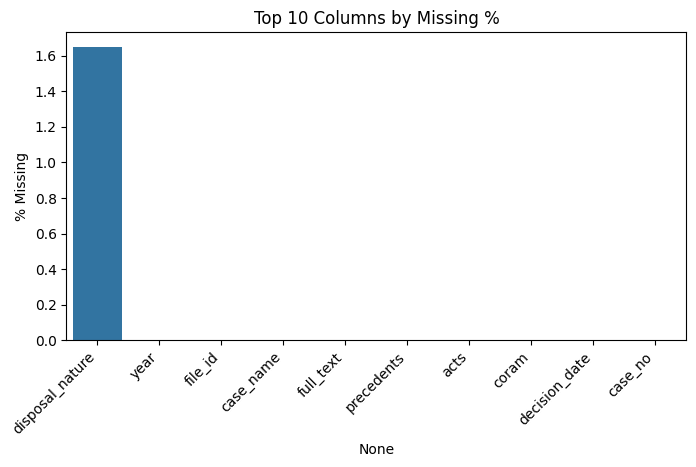

In [15]:
# Missing value audit
print("\n--- Missing Values (Top 15) ---")
missing = df.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(15).round(2))

plt.figure(figsize=(8,4))
sns.barplot(x=missing.head(10).index, y=missing.head(10).values)
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Columns by Missing %")
plt.ylabel("% Missing")
plt.show()


--- Top 10 Acts/Articles Distribution ---
acts
Article 226                               771
Article 14                                731
Article 32                                698
Article 136                               659
Article 21                                469
Evidence Act, 1872                        386
Article 142                               310
Land Acquisition Act, 1894                307
Arbitration and Conciliation Act, 1996    297
Article 19                                278
Name: count, dtype: int64


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_25844\252362746.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')


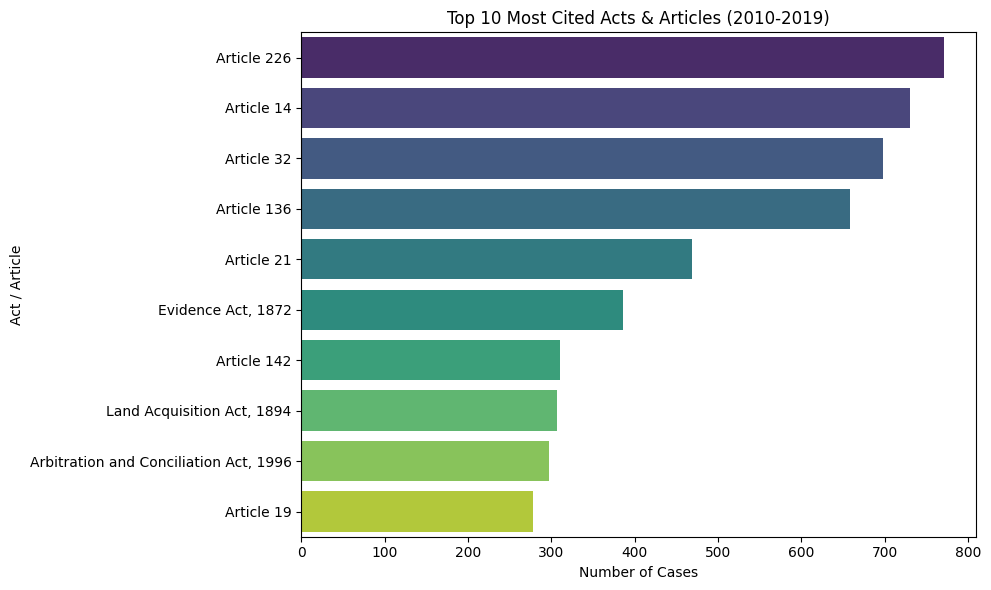

In [16]:
# 1. Explode the 'acts' column so each Act gets its own row
df_exploded = df.explode('acts')

#  Drop rows where 'acts' might be None (cases with no identified laws)
df_exploded = df_exploded.dropna(subset=['acts'])

# calculate the Top 10 Acts for a readable plot
top_10_acts = df_exploded['acts'].value_counts().nlargest(10)

print("\n--- Top 10 Acts/Articles Distribution ---")
print(top_10_acts)

# 4. Create the plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_acts.values, y=top_10_acts.index, palette='viridis')

plt.title(f"Top 10 Most Cited Acts & Articles ({start_year}-{end_year})")
plt.xlabel("Number of Cases")
plt.ylabel("Act / Article")
plt.tight_layout()
plt.show()